In [1]:
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import ast
from sklearn.ensemble import RandomForestRegressor
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re


spark = (
    SparkSession.builder.appName("MAST30034 Project 2")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/10 22:31:41 WARN Utils: Your hostname, PC, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/10/10 22:31:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/10 22:31:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/10 22:31:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/10/10 22:31:43 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [ ]:
rental_data = pd.read_csv('rea_data/domain/Data/vic_rentals_all_cleaned.csv')
dist_train_cbd = pd.read_csv('distance_csv/rentals_distances_to_train_stops_and_cbd.csv')
dist_school = pd.read_csv('distance_csv/rentals_distances_to_schools.csv')
dist_tram = pd.read_csv('distance_csv/rentals_distances_to_tram_stops.csv')
dist_bus = pd.read_csv('distance_csv/rentals_distances_to_bus_stops.csv')

dist_train_cbd = dist_train_cbd.rename(columns={'rental_id': 'listing_id', 'top_distances': 'train_dist'})
dist_school = dist_school.rename(columns={'rental_id': 'listing_id', 'top_distances': 'school_dist'})
dist_tram = dist_tram.rename(columns={'rental_id': 'listing_id', 'top_distances': 'tram_dist'})
dist_bus = dist_bus.rename(columns={'rental_id': 'listing_id', 'top_distances': 'bus_dist'})

In [3]:
merged_df = pd.merge(rental_data, dist_train_cbd, on='listing_id', how='inner')
merged_df = pd.merge(merged_df, dist_school, on='listing_id', how='inner')
merged_df = pd.merge(merged_df, dist_tram, on='listing_id', how='inner')
merged_df = pd.merge(merged_df, dist_bus, on='listing_id', how='inner')

In [4]:
def get_nearest(x):
    try:
        if isinstance(x, str):
            lst = ast.literal_eval(x)
            if isinstance(lst, list) and len(lst) > 0:
                return lst[0]
        elif isinstance(x, list) and len(x) > 0:
            return x[0]
    except (ValueError, SyntaxError):
        return np.nan
    return np.nan

merged_df["near_bus_dist"] = merged_df["bus_dist"].apply(get_nearest)
merged_df["near_train_dist"] = merged_df["train_dist"].apply(get_nearest)
merged_df["near_tram_dist"] = merged_df["tram_dist"].apply(get_nearest)
merged_df["near_school_dist"] = merged_df["school_dist"].apply(get_nearest)

merged_df = merged_df[~merged_df["near_bus_dist"].isna()]

usable_columns = ['listing_id', 'suburb', 'postcode', 'weekly_rent', 'bond', 'bedrooms', 'bathrooms', 'carspaces', 'property_type', 
'photo_count', 'video_count', 'floorplans_count', 'virtual_tour', 'structured_features', 'distance_to_cbd', 
'near_bus_dist', 'near_train_dist', 'near_tram_dist', 'near_school_dist']

merged_df_cleaned = merged_df[usable_columns]

In [5]:
# lemmentising the strucured features
merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.lower()
punctuation_pattern = r'[^\w\s]'
merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.replace(punctuation_pattern, '', regex=True)
merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.replace(r'\s', ",", regex=True)
merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.replace(r',,', ",", regex=True)

features_expanded = merged_df_cleaned['structured_features'].str.get_dummies(sep=',')
merged_features_expanded = pd.concat([merged_df_cleaned, features_expanded], axis=1)
merged_features_expanded = merged_features_expanded.drop(columns='structured_features')

/tmp/ipykernel_1040/2870864493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.lower()
/tmp/ipykernel_1040/2870864493.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.replace(punctuation_pattern, '', regex=True)
/tmp/ipykernel_1040/2870864493.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [6]:
'''merged_df_cleaned['structured_features'] = merged_df_cleaned['structured_features'].str.lower()
features_expanded = merged_df_cleaned['structured_features'].str.get_dummies(sep=', ')
merged_features_expanded = pd.concat([merged_df_cleaned, features_expanded], axis=1)
merged_features_expanded = merged_features_expanded.drop(columns='structured_features')
print(merged_df_cleaned['structured_features'])'''

feature_cols = [c for c in merged_features_expanded.columns if c not in usable_columns]

num_listings = merged_features_expanded[feature_cols].sum(axis=0)

# Average rent per feature
avg_rent = (merged_features_expanded[feature_cols].multiply(merged_features_expanded['weekly_rent'], axis=0)
            .sum(axis=0) / num_listings)

# Combine into a DataFrame
feature_stats = pd.DataFrame({
    'num_listings': num_listings,
    'avg_rent': avg_rent
})

# Sort by average rent descending
feature_stats_sorted = feature_stats.sort_values(by='avg_rent', ascending=False)

print(feature_stats_sorted[feature_stats_sorted['num_listings'] > 100].head(20))

               num_listings    avg_rent
spa                     166  924.066265
fireplaces              267  886.303371
pool                    455  869.767033
swimming                385  846.407792
city                    151  843.496689
gym                     562  808.167260
views                   224  804.361607
ensuites                200  792.845000
entertainment           560  767.714286
area                    675  766.214815
outdoor                 651  755.761905
ground                  134  753.059701
study                  1128  750.492908
rumpus                  163  748.680982
room                    266  740.714286
remote                  880  730.275000
furnished               862  723.996520
alarm                   436  720.919725
garage                  931  720.474758
intercom               1336  720.012725


In [7]:
train_x = merged_features_expanded.drop(columns=['weekly_rent', 'bond', 'listing_id', 'suburb', 'postcode', 'property_type'])
print(list(train_x.columns))
train_y = merged_features_expanded['weekly_rent']

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(train_x, train_y)
importances = pd.DataFrame({
    'feature': train_x.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# 6. Print top 20 features
print(importances.head(20))

['bedrooms', 'bathrooms', 'carspaces', 'photo_count', 'video_count', 'floorplans_count', 'virtual_tour', 'distance_to_cbd', 'near_bus_dist', 'near_train_dist', 'near_tram_dist', 'near_school_dist', '0', '05', '1', '2', '206', '214', '25m', '2nd', '3', '35', '4', '4th', '5', '55', '57', '6', '65', '66', '7', '78', '82', '85', '86', '900mm', 'a', 'above', 'aboveground', 'ac', 'access', 'accom', 'additional', 'adult', 'air', 'aircon', 'airconditioner', 'airconditioning', 'alarm', 'alarms', 'alfresco', 'all', 'allowed', 'amenities', 'ample', 'and', 'apartment', 'appliances', 'apron', 'area', 'areas', 'art', 'as', 'at', 'attic', 'audio', 'available', 'b2', 'back', 'backs', 'backyard', 'balcony', 'balconypatioterrace', 'barbeque', 'basement', 'bath', 'bathjacuzzi', 'bathroom', 'bathrooms', 'bathtub', 'bay', 'bbq', 'be', 'beach', 'beachcoastal', 'beautiflluy', 'bed', 'bedroom', 'bedrooms', 'below', 'bench', 'benches', 'benchtops', 'blinds', 'block', 'bottled', 'brand', 'brick', 'broadband', '

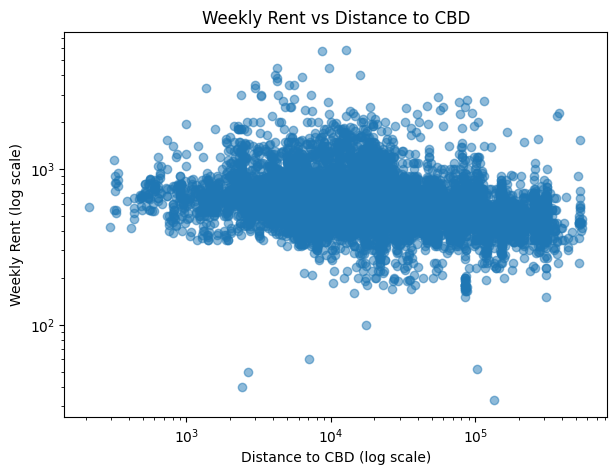

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(merged_df_cleaned["distance_to_cbd"], merged_df_cleaned["weekly_rent"], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Weekly Rent vs Distance to CBD")
plt.xlabel("Distance to CBD (log scale)")
plt.ylabel("Weekly Rent (log scale)")
plt.show()